# **Machine Learning Task: House Price Prediction (Regression)**

# **Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a **Machine Learning regression model**
that predicts the **price of a house** using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

# **Objective**

The objective of this task is to:

● Understand and explore the housing dataset.

● Perform data preprocessing including handling missing values, duplicates, and outliers.

● Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.

**Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

In [3]:
df = pd.read_csv("house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


**Check Dataset**

Shape of Dataset

In [4]:
df.shape

(1000, 8)



Rows: 1000

Columns: 8

Column Names

In [5]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

**Features available:**

Square_Footage

Num_Bedrooms

Num_Bathrooms

Year_Built

Lot_Size

Garage_Size

Neighborhood_Quality

House_Price (Target)

Dataset Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


All columns are numerical

No datatype issues

Statistical Summary

In [7]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


Average house price ≈ 618,861

Average square footage ≈ 2815

Bedrooms range from 1 to 5

Neighborhood quality ranges 1–10

**Handle Missing Values**

In [8]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


No missing values present in dataset

**Remove Duplicate Records**

In [9]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found

**Univariate Analysis**

Univariate analysis studies one variable at a time.

Distribution of House Prices

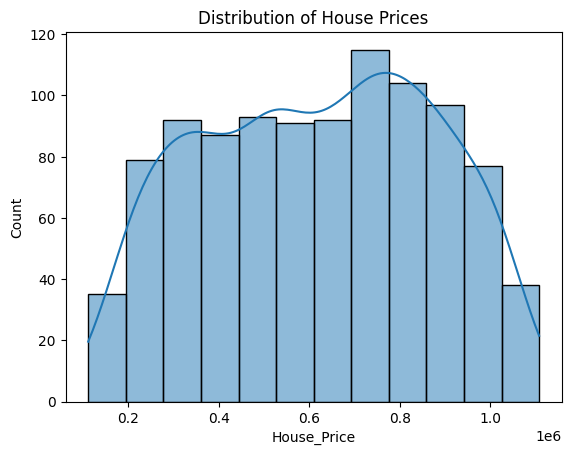

In [10]:
sns.histplot(df["House_Price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

Insight:

House prices are normally distributed.

Bedrooms Distribution

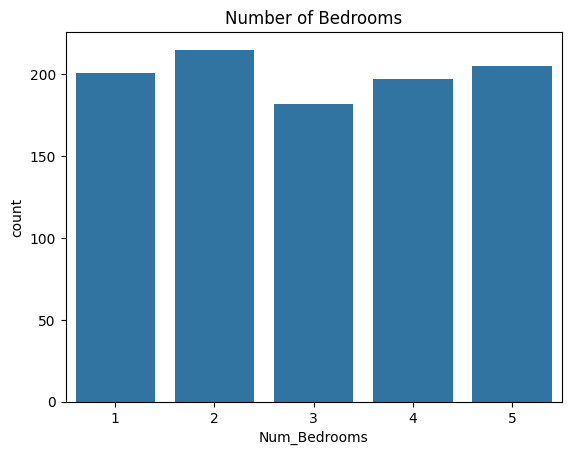

In [11]:
sns.countplot(x=df["Num_Bedrooms"])
plt.title("Number of Bedrooms")
plt.show()

Insight:

Most houses have 2–4 bedrooms.

Square Footage Distribution

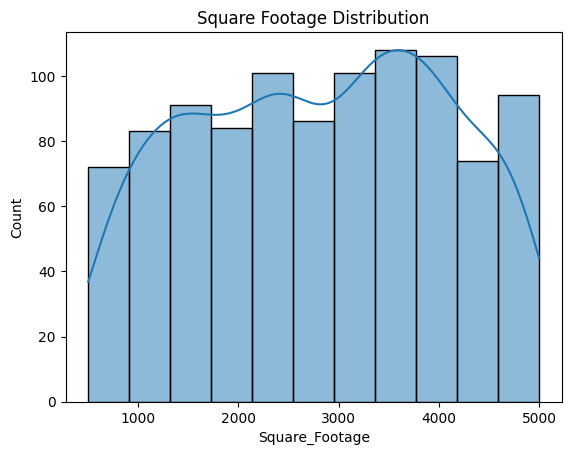

In [12]:
sns.histplot(df["Square_Footage"], kde=True)
plt.title("Square Footage Distribution")
plt.show()

Insight:

Houses range roughly 500–5000 sq ft.

**Bivariate Analysis**

Bivariate analysis studies the relationship between two variables.

Square Footage vs House Price

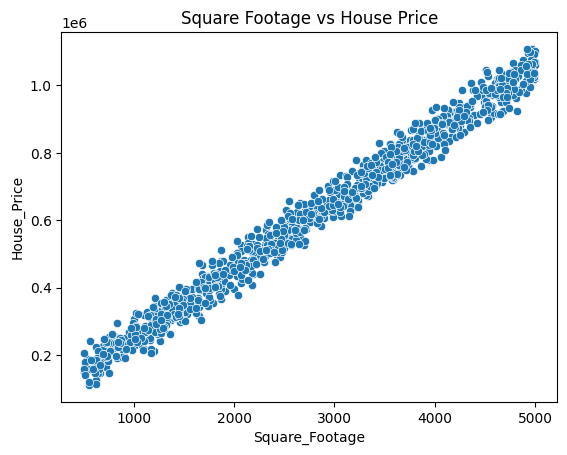

In [13]:
sns.scatterplot(x="Square_Footage", y="House_Price", data=df)
plt.title("Square Footage vs House Price")
plt.show()

Insight:

➡Strong positive relationship

➡Larger houses tend to have higher prices

Lot Size vs House Price

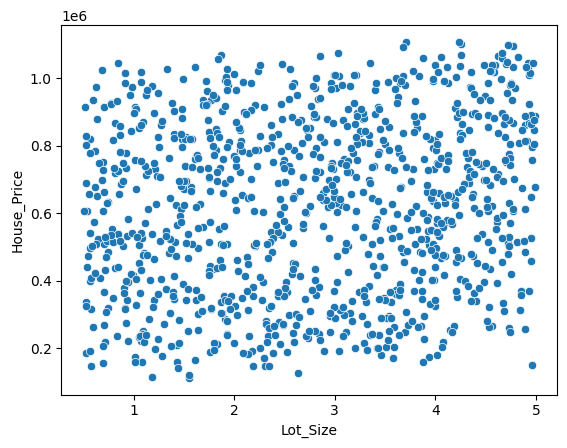

In [14]:
sns.scatterplot(x="Lot_Size", y="House_Price", data=df)
plt.show()

Insight:

Slight positive relationship

Bedrooms vs Price

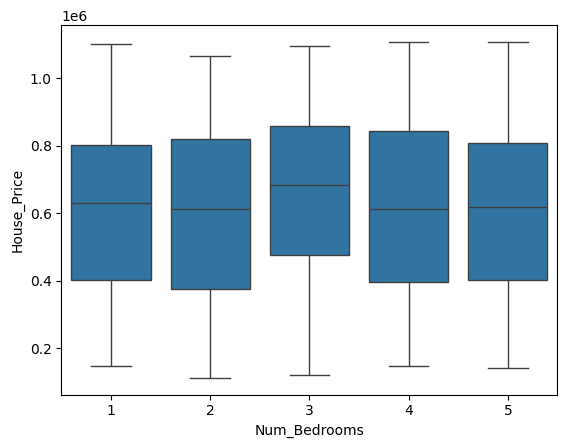

In [15]:
sns.boxplot(x="Num_Bedrooms", y="House_Price", data=df)
plt.show()

Insight:

Houses with more bedrooms tend to have higher prices

**Correlation Heatmap**

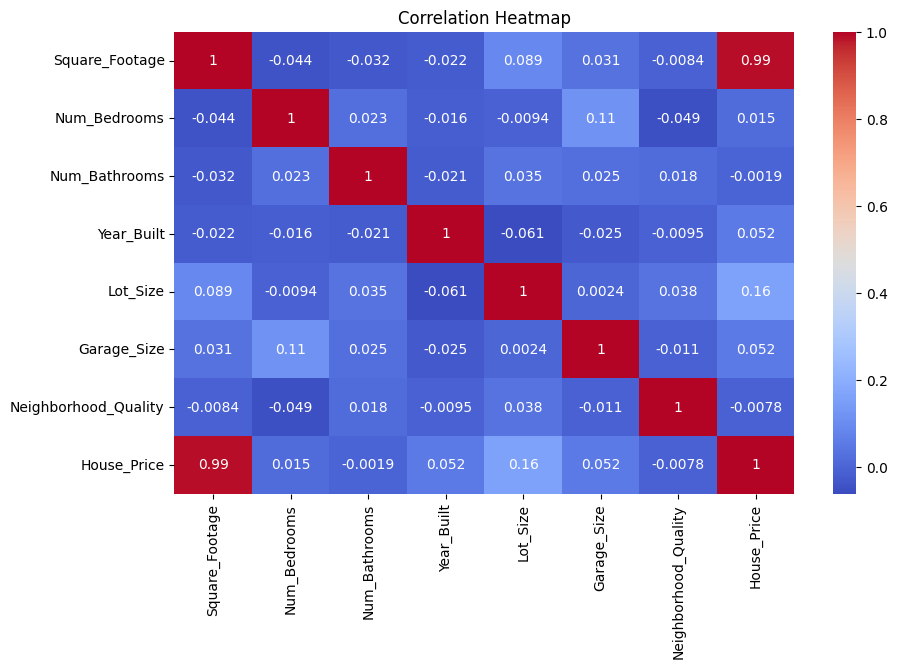

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Important Insight:

| Feature        | Correlation with Price |
| -------------- | ---------------------- |
| Square_Footage | **0.99 (Very Strong)** |
| Lot_Size       | 0.16                   |
| Garage_Size    | 0.05                   |
| Year_Built     | 0.05                   |
| Bedrooms       | 0.01                   |


Key takeaway:

➡ Square_Footage is the most important predictor of house price

**Detect Outliers**

Using IQR method

In [17]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print(outliers)

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


Result:

No significant outliers detected

Observation:

➡Dataset is clean

➡No major extreme values

**Key EDA Insights**

➡Dataset contains 1000 houses with 8 features.

➡There are no missing values or duplicates.

➡Square footage strongly influences house price.

➡Larger houses and larger lot sizes generally have higher prices.

➡Number of bedrooms and bathrooms have weak correlation with price.

➡The dataset is well balanced with no major outliers.

➡Most house prices fall between 400,000 and 850,000.

➡The dataset is suitable for regression modeling.